In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url="https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df=pd.read_csv(url)


print(df.head())
print(df.shape)
print(df.columns)
print(df.info())


       country  year         pop continent  lifeExp   gdpPercap
0  Afghanistan  1952   8425333.0      Asia   28.801  779.445314
1  Afghanistan  1957   9240934.0      Asia   30.332  820.853030
2  Afghanistan  1962  10267083.0      Asia   31.997  853.100710
3  Afghanistan  1967  11537966.0      Asia   34.020  836.197138
4  Afghanistan  1972  13079460.0      Asia   36.088  739.981106
(1704, 6)
Index(['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB
None


In [2]:
df = df.rename(columns={
    "lifeExp": "life_expectancy",
    "pop": "population",
    "gdpPercap": "gdp_per_capita"
})

print(df.head())
print(df.columns)

       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106
Index(['country', 'year', 'population', 'continent', 'life_expectancy',
       'gdp_per_capita'],
      dtype='object')


In [3]:
print("Missing values in each column:")
print(df.isna().sum)

print("Number of duplicate rows:", df.duplicated().sum())

Missing values in each column:
<bound method DataFrame.sum of       country   year  population  continent  life_expectancy  gdp_per_capita
0       False  False       False      False            False           False
1       False  False       False      False            False           False
2       False  False       False      False            False           False
3       False  False       False      False            False           False
4       False  False       False      False            False           False
...       ...    ...         ...        ...              ...             ...
1699    False  False       False      False            False           False
1700    False  False       False      False            False           False
1701    False  False       False      False            False           False
1702    False  False       False      False            False           False
1703    False  False       False      False            False           False

[1704 rows x 

In [4]:
df_clean = df.copy()

# Remove exact duplicate rows if any
if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates()

# Strip extra spaces from text columns
for col in ["country", "continent"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Ensure expected data types
df_clean["year"] = df_clean["year"].astype(int)
df_clean["population"] = df_clean["population"].astype(float)
df_clean["life_expectancy"] = df_clean["life_expectancy"].astype(float)
df_clean["gdp_per_capita"] = df_clean["gdp_per_capita"].astype(float)

print(df_clean.dtypes)
print(df_clean.head())


country             object
year                 int64
population         float64
continent           object
life_expectancy    float64
gdp_per_capita     float64
dtype: object
       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106


In [5]:
# dirty_demo = df_clean.head(12).copy()

# # Deliberately introduce missing values for teaching practice
# dirty_demo.loc[2, "life_expectancy"] = np.nan
# dirty_demo.loc[5, "gdp_per_capita"] = np.nan

# print(dirty_demo)
# print(dirty_demo.isna().sum())

# # Fill missing numerical values using median
# clean_demo = dirty_demo.copy()
# clean_demo["life_expectancy"] = clean_demo["life_expectancy"].fillna(clean_demo["life_expectancy"].median())
# clean_demo["gdp_per_capita"] = clean_demo["gdp_per_capita"].fillna(clean_demo["gdp_per_capita"].median())

# print(clean_demo.isna().sum())
# print(clean_demo)


In [6]:
num_of_country=df["country"].nunique()
print("Number of countries:", num_of_country)
num_of_cont=df["continent"].nunique()
print("Number of continents:", num_of_cont)

Number of countries: 142
Number of continents: 5


In [7]:
latest_year=df["year"].max()
latest_data=df[df["year"]==latest_year].copy()
latest_data

,country,year,population,continent,life_expectancy,gdp_per_capita
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,"Yemen, Rep.",2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


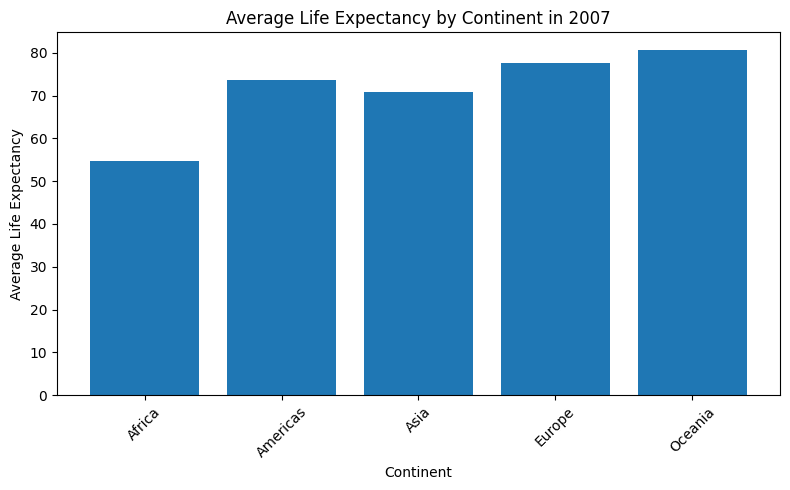

In [10]:
# plt.plot(df["continent"],df["life_expectancy"])
# plt.show()
# Latest year ke data me continent-wise average life expectancy
continent_life = latest_data.groupby("continent")["life_expectancy"].mean()

plt.figure(figsize=(8, 5))
plt.bar(continent_life.index, continent_life.values)

plt.title(f"Average Life Expectancy by Continent in {latest_year}")
plt.xlabel("Continent")
plt.ylabel("Average Life Expectancy")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

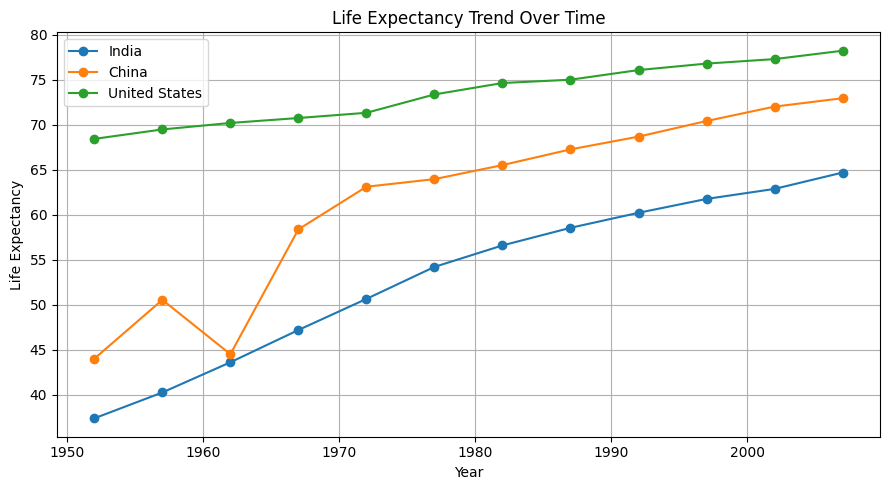

In [11]:
# plt.plot(df["life_expectancy"],df["year"])
# plt.show()
selected_countries = ["India", "China", "United States"]
trend_df = df_clean[df_clean["country"].isin(selected_countries)]

plt.figure(figsize=(9, 5))

for country in selected_countries:
    country_df = trend_df[trend_df["country"] == country]
    plt.plot(country_df["year"],
             country_df["life_expectancy"],
             marker="o",
             label=country)

plt.title("Life Expectancy Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

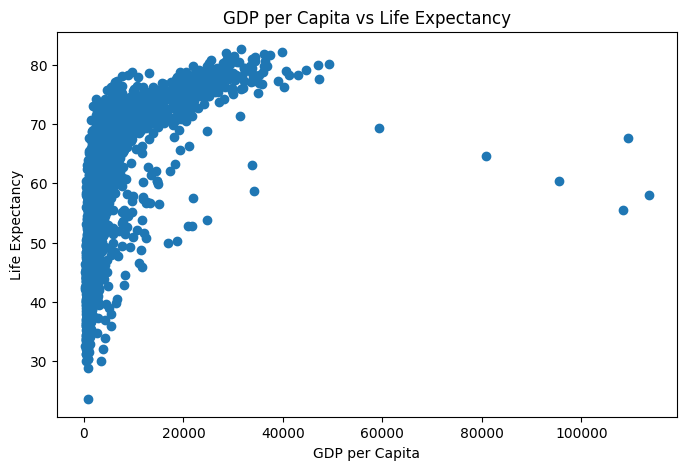

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(df["gdp_per_capita"], df["life_expectancy"])

plt.title("GDP per Capita vs Life Expectancy")
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")

plt.show()